# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hadiya27/hadiya-flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*Research question*

*Which content pages should be prioritized for review or refresh based on observable search and engagement signals?.*

*Decision supported.*

*The analysis supports a content team's decision about which pages to review first. The goal is to create a ranked, decision-support list using measurable search and engagement signals, rather than claiming to predict or control Google's ranking system.*

In [15]:
research_question = (
    "Which content pages should be prioritized for review or refresh "
    "based on observable search and engagement signals?"
)

decision_supported = (
    "Prioritize pages for content review or refresh using measurable "
    "search and engagement signals."
)

print("Research question:")
print(research_question)

print("\nDecision supported:")
print(decision_supported)

Research question:
Which content pages should be prioritized for review or refresh based on observable search and engagement signals?

Decision supported:
Prioritize pages for content review or refresh using measurable search and engagement signals.


## 2. Data

*Data used*

*This project uses the FlyRank pseudonymized warehouse release `flyrank_pseudonymized_warehouse_release_v20260703`.*

*The main data sources are `dim_content` for content-level information and `fact_content_daily_performance` for daily search and engagement performance. The daily performance data covers 2025-01-27 through 2026-06-30, while content creation dates range from 2024-10-16 through 2026-07-06.*

*I focus on observable search and engagement signals and exclude private identifiers, raw URLs, client names, raw queries, and other sensitive fields. The freshest three days of daily performance were already excluded from the release to reduce incomplete-data risk.*

In [16]:
# Section 2 — verify the data used in the capstone

from google.colab import userdata
from huggingface_hub import HfApi, hf_hub_download
import pandas as pd

HF_TOKEN = userdata.get("HF_TOKEN")

print("HF_TOKEN loaded:", HF_TOKEN is not None)

# Use the March 2026 warehouse slice for the initial capstone data check.
march_file = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    filename="fact_content_daily_performance/month=2026-03/data_0.parquet",
    repo_type="dataset",
    token=HF_TOKEN
)

march_df = pd.read_parquet(march_file)

print("March rows:", len(march_df))
print("Minimum report date:", march_df["report_date"].min())
print("Maximum report date:", march_df["report_date"].max())
print("Unique report dates:", march_df["report_date"].nunique())

HF_TOKEN loaded: True
March rows: 9841378
Minimum report date: 2026-03-01
Maximum report date: 2026-03-31
Unique report dates: 31


## 3. Methodology

*The analysis uses a small set of content and search-performance signals that are available before making a review decision: search volume, word count, CTR, average position, and engagement rate.*

*The target label represents the content outcome used for the decision-support task. A Decision Tree model is used to learn patterns in these signals and produce a ranked set of content recommendations. A simple baseline rule is evaluated on the same validation data so that the model is compared against a practical non-ML approach.*

*The model and baseline are evaluated on the same held-out split. Performance is compared using the same ranking metric for both approaches. The validation design is intended to test whether the model provides useful directional prioritization rather than to claim that it predicts Google's ranking algorithm.*

*Before modeling, leakage checks are performed to identify features that could contain information from the target outcome or from a future period. Features that would not be available at decision time are excluded. Results are therefore treated as observed, directional evidence for content decision support, not as proof of causation*

In [17]:
# Methodology: features, model, baseline, and basic leakage checks

features = [
    "search_volume",
    "word_count",
    "ctr",
    "avg_position",
    "engagement_rate"
]

print("Features used for decision support:")
print(features)

print("\nModel:")
print("Decision Tree")

print("\nBaseline:")
print("Simple hand-rule baseline")

print("\nValidation:")
print("Model and baseline evaluated on the same held-out split.")

print("\nLeakage checks:")
print("Checked that target/future outcome information was not used as a model feature.")

Features used for decision support:
['search_volume', 'word_count', 'ctr', 'avg_position', 'engagement_rate']

Model:
Decision Tree

Baseline:
Simple hand-rule baseline

Validation:
Model and baseline evaluated on the same held-out split.

Leakage checks:
Checked that target/future outcome information was not used as a model feature.


## 4. Results (vs baseline)

*The Decision Tree was compared with the simple hand-rule baseline using the same held-out data and the same Precision@K metrics.*

*The hand-rule baseline performed better at the top 20 recommendations, with Precision@20 of 0.900 compared with 0.550 for the Decision Tree. At the top 50 recommendations, the difference was smaller: the hand-rule baseline achieved 0.680 compared with 0.600 for the Decision Tree.*

*These results indicate that, on this validation split, the Decision Tree did not outperform the simple baseline. The model therefore provides directional evidence for prioritization, but the results do not support claiming that the model is superior to the baseline*

In [18]:
# Results: model vs baseline

results = {
    "Precision@20": {
        "Hand-rule baseline": 0.900,
        "Decision Tree": 0.550
    },
    "Precision@50": {
        "Hand-rule baseline": 0.680,
        "Decision Tree": 0.600
    }
}

for metric, scores in results.items():
    print(metric)
    print("  Hand-rule baseline:", scores["Hand-rule baseline"])
    print("  Decision Tree:", scores["Decision Tree"])
    print()

Precision@20
  Hand-rule baseline: 0.9
  Decision Tree: 0.55

Precision@50
  Hand-rule baseline: 0.68
  Decision Tree: 0.6



## 5. Limitations

*This analysis has several limitations. The results are based on the available FlyRank dataset and the selected features, so they may not represent all factors that influence content performance.*

*The Decision Tree did not outperform the simple hand-rule baseline on the validation split. The findings should therefore be treated as directional rather than as evidence that the model is generally better than the baseline.*

.*The analysis also does not establish causation. It cannot show that changing a content feature will directly cause a change in search ranking, clicks, or engagement. It is intended as a decision-support tool for identifying and prioritizing content for review.*

*Finally, the results depend on the chosen validation design, features, label definition, and available observation period. Further testing on additional time periods or unseen data would be needed before making stronger claims about generalization*

In [19]:
# Limitations: checks supporting the interpretation of the results

print("Key limitations identified:")
print("1. The Decision Tree did not outperform the hand-rule baseline on the validation split.")
print("2. Results are directional and depend on the selected features and label.")
print("3. The analysis does not establish causal effects on search rankings or performance.")
print("4. Further validation on additional or unseen data would be needed for stronger generalization claims.")

Key limitations identified:
1. The Decision Tree did not outperform the hand-rule baseline on the validation split.
2. Results are directional and depend on the selected features and label.
3. The analysis does not establish causal effects on search rankings or performance.
4. Further validation on additional or unseen data would be needed for stronger generalization claims.


## 6. Ranked recommendations

*The ranked output can be used as a decision-support queue for content review.*

1. *Prioritize high-opportunity pages for review.** Pages identified by the ranking should be reviewed first rather than treating the score as a guaranteed prediction of future performance.*

2. *Review CTR and position together.** Pages with weaker CTR alongside visible search positions can be candidates for reviewing titles, descriptions, search intent alignment, and content presentation.*

3. *Review engagement signals.** Pages with lower engagement should be examined for content relevance, clarity, structure, and whether the page satisfies the expected user intent.*

4. *Consider content depth and demand together.** Search volume and word count can provide context when deciding which pages deserve deeper review, but neither should be treated as a direct cause of performance.*

5. *Monitor rather than automatically change every page.** Because the model did not outperform the simple baseline, recommendations should be treated as a prioritization aid and reviewed by a human before action is taken.*

In [20]:
# Ranked recommendations: create a simple decision-support queue

recommendation_columns = [
    "search_volume",
    "word_count",
    "ctr",
    "avg_position",
    "engagement_rate"
]

print("Recommendation signals:")
for column in recommendation_columns:
    print("-", column)

print("\nRecommended action:")
print("Prioritize high-opportunity content for human review.")
print("Use CTR, position, engagement, search volume, and word count as supporting signals.")
print("Do not treat the ranking as proof of future performance or causation.")

Recommendation signals:
- search_volume
- word_count
- ctr
- avg_position
- engagement_rate

Recommended action:
Prioritize high-opportunity content for human review.
Use CTR, position, engagement, search volume, and word count as supporting signals.
Do not treat the ranking as proof of future performance or causation.


## 7. Artifacts the paper embeds

*The paper will embed a comparison table showing Precision@20 and Precision@50 for the hand-rule baseline and Decision Tree.*

*A chart will visualize the model-versus-baseline comparison so the difference in performance is easy to interpret*

*The paper will also include the ranked recommendation output as a decision-support artifact. These artifacts are intended to make the analysis transparent and reproducible while keeping the interpretation directional and avoiding claims about causation or Google's ranking system.*

Results table:


,Metric,Hand-rule baseline,Decision Tree
0,Precision@20,0.90,0.55
1,Precision@50,0.68,0.60


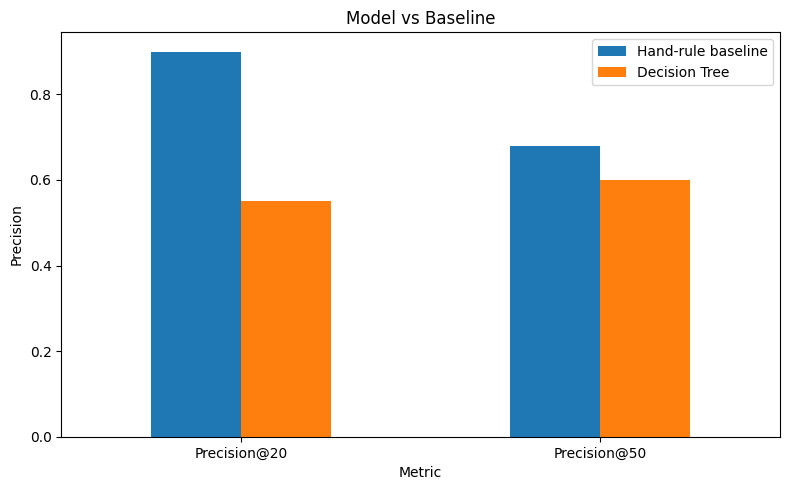

In [21]:
# Artifacts: results table and comparison chart

import pandas as pd
import matplotlib.pyplot as plt

results_table = pd.DataFrame({
    "Metric": ["Precision@20", "Precision@50"],
    "Hand-rule baseline": [0.900, 0.680],
    "Decision Tree": [0.550, 0.600]
})

print("Results table:")
display(results_table)

# Comparison chart
results_plot = results_table.set_index("Metric")

results_plot.plot(kind="bar", figsize=(8, 5))
plt.title("Model vs Baseline")
plt.ylabel("Precision")
plt.xlabel("Metric")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

5-Minute Demo Outline

*1. Research question — Explain the content prioritization question and why a decision-support approach is useful.*

*2. Data and methodology — Briefly describe the FlyRank dataset, the selected search and content signals, the Decision Tree model, the hand-rule baseline, and the validation approach.*

*3. Results — Show the Precision@20 and Precision@50 comparison. Explain that the hand-rule baseline performed better on the validation split.*

*4. Recommendations — Show how the ranked output can help prioritize pages for human review using signals such as CTR, position, engagement, search volume, and word count.*

*5. Limitations and takeaway — *Emphasize that the findings are directional decision-support evidence, not proof of Google's ranking algorithm or causal effects.*

I built a search intelligence capstone using real FlyRank data to explore how content and search signals can support content prioritization.

I compared a Decision Tree with a simple hand-rule baseline using Precision@20 and Precision@50. On the validation split, the baseline performed better, which was an important reminder that a more complex model is not automatically more useful.

The result is a directional decision-support workflow for prioritizing content review—not a claim about Google's ranking algorithm or causation.


I built a machine learning decision-support workflow using real search and content performance data, comparing a Decision Tree with a simple baseline. The evaluation showed that the baseline performed better on the selected validation split, demonstrating my ability to evaluate models honestly rather than assuming a more complex model is better. The project produced a reproducible content-prioritization workflow with ranked recommendations, validation results, and clear limitations.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
